In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("spam.csv",encoding="latin-1")
df.shape


(5572, 5)

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4257,ham,I am late. I will be there at,NaN,NaN,NaN
2157,ham,Sad story of a Man - Last week was my b'day. M...,NaN,NaN,NaN
3170,ham,Still otside le..u come 2morrow maga..,NaN,NaN,NaN
928,ham,Oh all have to come ah?,NaN,NaN,NaN
5152,ham,Idk. I'm sitting here in a stop and shop parki...,NaN,NaN,NaN


In [4]:
# 1: Data Cleaning
# 2: EDA
# 3: Text Preprocessing
# 4: Model Building
# 5: Evaluation and refining
# 6: Impletation
# 7: Deploy

# Data Cleaning

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# Drop last three columns
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])
df.sample(5)

,v1,v2
3154,ham,Ok...
90,ham,Yeah do! DonÛ÷t stand to close tho- youÛ÷ll ...
3658,ham,Wait.i will come out.. &lt;#&gt; min:)
2674,ham,I am 6 ft. We will be a good combination!
3073,ham,Don know. I did't msg him recently.


In [7]:
# rename the columns
df = df.rename(columns={'v1':'target','v2':'text'})
df.sample(5)

,target,text
1293,ham,Happy birthday... May all ur dreams come true...
3808,ham,At the funeral home with Audrey and dad
5234,ham,Ok cool. See ya then.
550,ham,Imagine you finally get to sink into that bath...
5164,spam,Congrats 2 mobile 3G Videophones R yours. call...


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [9]:
df['target'] = encoder.fit_transform(df['target'])





In [10]:
df.sample(5)

,target,text
4993,0,My drive can only be read. I need to write
514,1,"You are guaranteed the latest Nokia Phone, a 4..."
3774,0,Hi! You just spoke to MANEESHA V. We'd like to...
3604,0,Jordan got voted out last nite!
4085,0,Lemme know when you're here


In [11]:
# check missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
# check duplicates
df.duplicated().sum()

np.int64(403)

In [13]:
# see 403 duplicates occured..we should drop
df = df.drop_duplicates() # keep='first' by default in panda

In [14]:
df.duplicated().sum() # again check duplicates
df.shape

(5169, 2)

# EDA

In [15]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# want to check How many ham or spam
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt

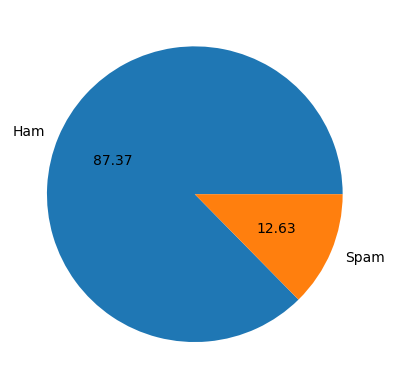

In [18]:
plt.pie(df['target'].value_counts(),labels=['Ham','Spam'],autopct="%0.2f")
plt.show()

In [19]:
# pie chart shows our data is imbalanced

In [20]:
import nltk
nltk.download('punkt')# use for text to convert into sentences and words
nltk.download('punkt_tab')# set rule for tokenization to split text into sentences and words


[nltk_data] Downloading package punkt to C:\Users\Ashwa
[nltk_data]     Asghar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Ashwa
[nltk_data]     Asghar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df['num_characters']=df['text'].apply(len)


In [22]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
# text into num of words
df['num_words']= df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [24]:
# text into num of sentences
df['num_sentences']= df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
# for Ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
# for spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()
# we can clearly see Spam messages are largest in words

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

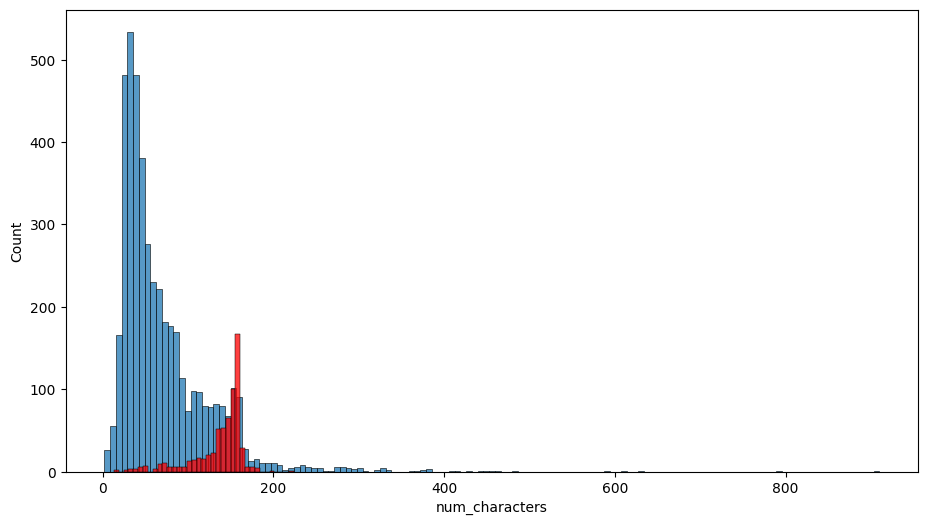

In [28]:
plt.figure(figsize=(11,6))
import seaborn as sns
sns.histplot(df[df['target']== 0]['num_characters']) # ham
sns.histplot(df[df['target']== 1]['num_characters'],color='red') # spam

In [29]:
# spam has no of characters more
# spam has no of words more


<Axes: xlabel='num_words', ylabel='Count'>

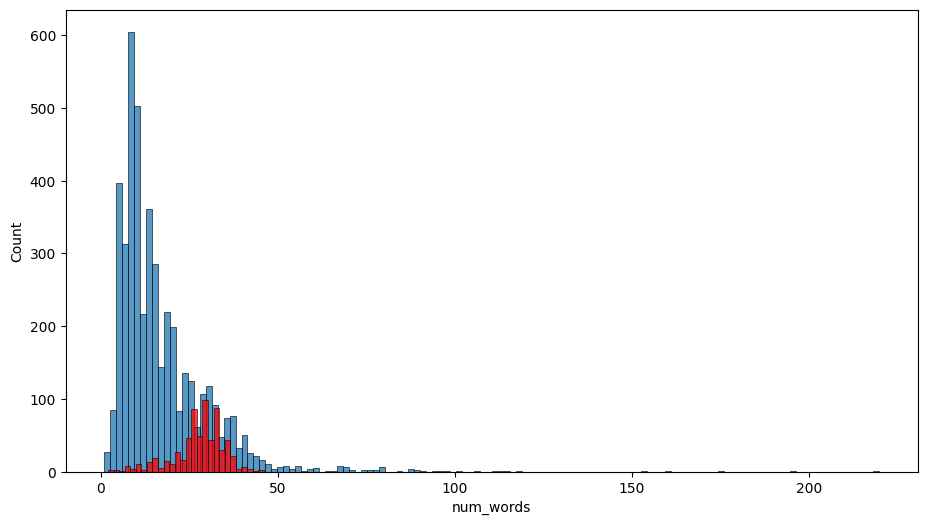

In [30]:
plt.figure(figsize=(11,6))
import seaborn as sns
sns.histplot(df[df['target']== 0]['num_words']) # ham
sns.histplot(df[df['target']== 1]['num_words'],color='red') # spam

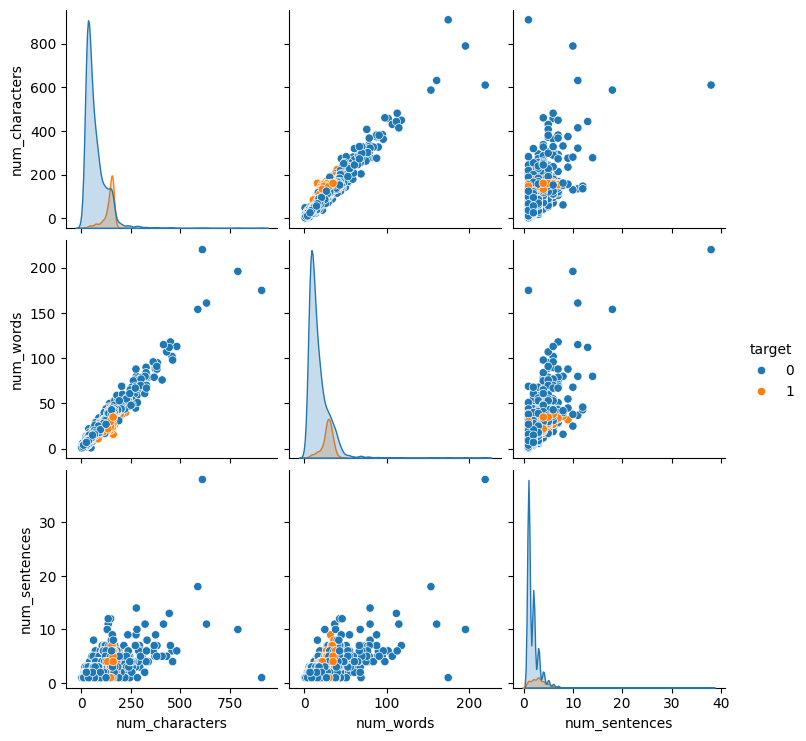

In [31]:
sns.pairplot(df,hue='target')

<Axes: >

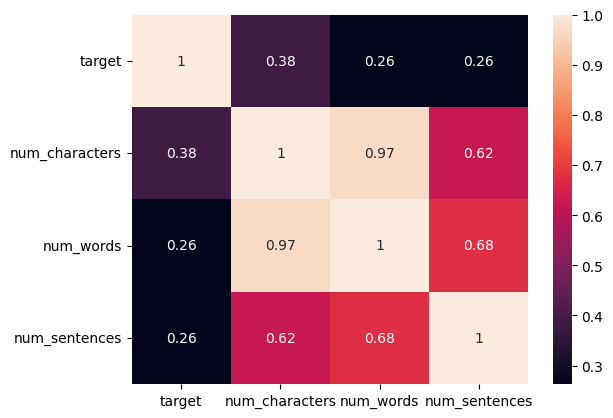

In [32]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

num of characters has 38% relationship with target(1)...mean num of characters increase ..spam email ...increase.........In this data,multicollinearity exist...we will take no of characters vs target

# Data preprocessing
- lowercase
- Tokenization(break into words)
- remove special characters
- remove stopwords and punctuation
- stemming

In [33]:
nltk.download('stopwords')# use for removing stop words like is, a, the
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to C:\Users\Ashwa
[nltk_data]     Asghar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [34]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [35]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [36]:
def tranform_text(text):
    texts = text.lower()
    texts = nltk.word_tokenize(texts)
    y = []
    for i in texts:
        if i.isalnum():  # alphanumeric
            y.append(i)
    textt = y[:]
    y.clear()
    for i in textt:
        if i not in stopwords.words('english') and string.punctuation:
            y.append(i)
    textt = y[:]
    y.clear()
    for i in textt:
        y.append(ps.stem(i))
    return " ".join(y)
   
   

In [37]:
df['tranform_text'] = df['text'].apply(tranform_text)

In [38]:
df.head()

,target,text,num_characters,num_words,num_sentences,tranform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [39]:
from wordcloud import WordCloud
wc = WordCloud(width = 500,height=500,min_font_size=10,background_color='white')

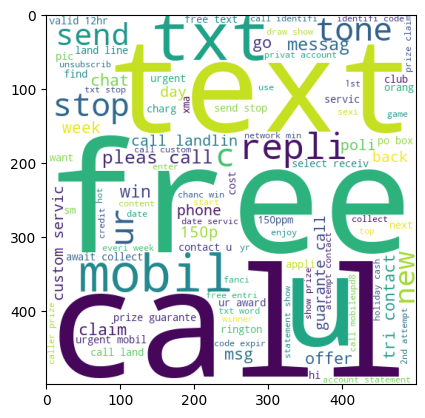

In [40]:
spam_wcc = wc.generate(df[df['target']==1]['tranform_text'].str.cat(sep =" "))
plt.imshow(spam_wcc)


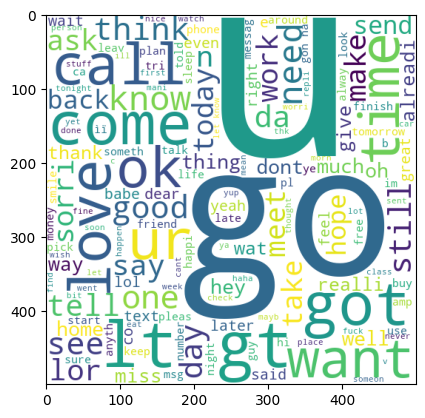

In [41]:
ham_wcc = wc.generate(df[df['target']==0]['tranform_text'].str.cat(sep =" "))
plt.imshow(ham_wcc)


In [42]:
# for spam
split_tranform_text = []
for line in df[df['target']== 1]['tranform_text'].tolist():
    for msg in line.split(" "):
     split_tranform_text.append(msg)

split_tranform_text


['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [43]:
len(split_tranform_text)

9939

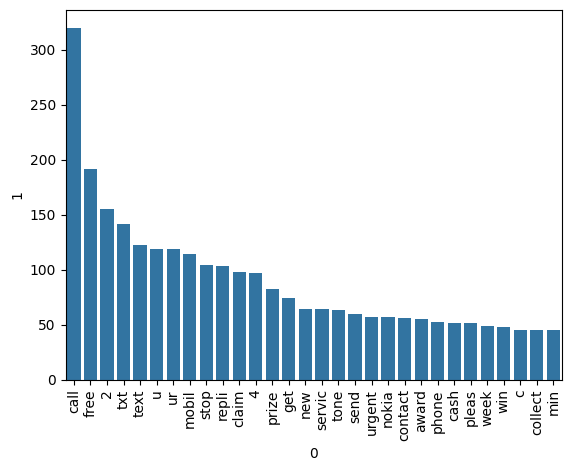

In [44]:
# for spam
from collections import Counter
dfc = pd.DataFrame(Counter(split_tranform_text).most_common(30))
sns.barplot(data=dfc,x=0,y=1)
plt.xticks(rotation='vertical')
plt.show()


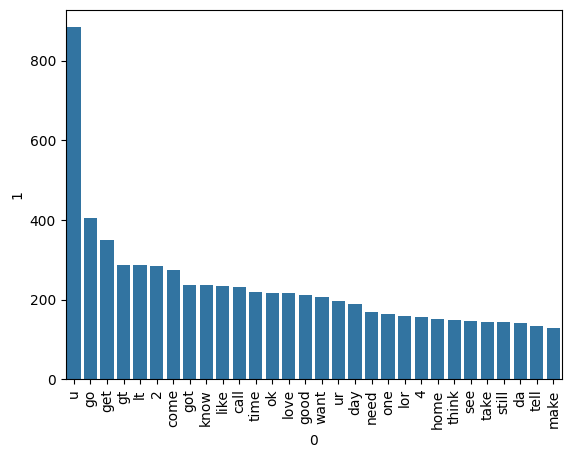

In [45]:
# for spam
split_tranform_ham = []
for line in df[df['target']== 0]['tranform_text'].tolist():
    for msg in line.split(" "):
     split_tranform_ham.append(msg)

# split_tranform_ham

from collections import Counter
dfch = pd.DataFrame(Counter(split_tranform_ham).most_common(30))
sns.barplot(data=dfch,x=0,y=1)
plt.xticks(rotation='vertical')
plt.show()



# Model Building

In [46]:
# we will use Navie Bayes Model because this model is best for text classification
# first we will convert text in numerical(Vector)
# we will use bag of words and TDif

In [47]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tf = TfidfVectorizer(max_features=3000)



In [48]:
x = df['tranform_text'].values
x

array(['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
       'ok lar joke wif u oni',
       'free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18',
       ..., 'piti mood suggest',
       'guy bitch act like interest buy someth els next week gave us free',
       'rofl true name'], shape=(5169,), dtype=object)

In [49]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=2)

In [51]:
x_train_vec = tf.fit_transform(x_train)
x_test_vec = tf.transform(x_test)




In [52]:
print(x_train_vec)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29784 stored elements and shape (4135, 3000)>
  Coords	Values
  (0, 1369)	0.7163223464659046
  (0, 265)	0.4460239676282434
  (0, 2672)	0.34073582132989116
  (0, 2859)	0.4145407293829939
  (1, 991)	0.6918104873706562
  (1, 2240)	0.72207911586195
  (2, 2876)	0.4162035337682305
  (2, 554)	0.48874443304799525
  (2, 2793)	0.3252330274382196
  (2, 483)	0.5064499671585635
  (2, 890)	0.4750109538441103
  (3, 2067)	1.0
  (4, 1838)	0.2590777288832844
  (4, 2849)	0.1792395038694223
  (4, 2166)	0.33548837099506235
  (4, 549)	0.29073283073665984
  (4, 2085)	0.23717395722279133
  (4, 2493)	0.2939541591963298
  (4, 1899)	0.21389602793512047
  (4, 650)	0.345187984296439
  (4, 768)	0.33548837099506235
  (4, 2610)	0.357692960757048
  (4, 1873)	0.24402577881868465
  (4, 1786)	0.3099384354505286
  (5, 1168)	0.49171332442621307
  :	:
  (4130, 521)	0.4528340640459642
  (4130, 1304)	0.6273144003131612
  (4130, 2089)	0.6335755310926664
  (4131, 247

In [53]:
print(x_test_vec)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6701 stored elements and shape (1034, 3000)>
  Coords	Values
  (0, 290)	0.6860831991941136
  (0, 1655)	0.727523088144679
  (1, 1336)	0.751642616002278
  (1, 1672)	0.6595706010801664
  (3, 1104)	0.3064720428935221
  (3, 2177)	0.7085707942433112
  (3, 2867)	0.6356117655220632
  (4, 22)	0.28273691372637927
  (4, 52)	0.23813373298308352
  (4, 59)	0.26830079615517627
  (4, 124)	0.23813373298308352
  (4, 521)	0.11868624163084975
  (4, 531)	0.2291859725927246
  (4, 699)	0.28273691372637927
  (4, 1037)	0.1525289907553646
  (4, 1176)	0.21345502699183483
  (4, 1699)	0.20760520633324558
  (4, 1842)	0.1834700810799881
  (4, 1862)	0.2580582077351306
  (4, 1897)	0.2747921449223313
  (4, 1968)	0.28273691372637927
  (4, 2067)	0.16921701710867407
  (4, 2139)	0.2291859725927246
  (4, 2246)	0.25386467858397327
  (4, 2740)	0.1640976150093375
  :	:
  (1031, 521)	0.17082528498995744
  (1031, 643)	0.3392107209207192
  (1031, 885)	0.282912696898944

In [54]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score,confusion_matrix
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [55]:
gnb.fit(x_train_vec.toarray(),y_train)
y_predict = gnb.predict(x_test_vec.toarray())
print(accuracy_score(y_test,y_predict))
print(precision_score(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

0.8462282398452611
0.4578313253012048
[[761 135]
 [ 24 114]]


In [56]:
mnb.fit(x_train_vec,y_train)
y_predict2 = mnb.predict(x_test_vec)
print(accuracy_score(y_test,y_predict2))
print(precision_score(y_test,y_predict2))
print(confusion_matrix(y_test,y_predict2))

0.9671179883945842
1.0
[[896   0]
 [ 34 104]]


In [57]:
bnb.fit(x_train_vec,y_train)
y_predict3 = bnb.predict(x_test_vec)
print(accuracy_score(y_test,y_predict3))
print(precision_score(y_test,y_predict3))
print(confusion_matrix(y_test,y_predict3))

0.9806576402321083
1.0
[[896   0]
 [ 20 118]]


Data is imbalanced so precision matter more
- we will use tfidfVectorizer Instead of Bag of words(for just Experiment) coz this gives best accuracy or precision of bnb and mnb

In [58]:
# tdidf --> bnb

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [60]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
bnb = BernoulliNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)


In [61]:
clfs = {
    "SVC": svc,
    "KNC": knc,
    "BNB": bnb,
    "DTC": dtc,
    "LRC": lrc,
    "RFC": rfc,
    "ABC": abc,
    "BC": bc,
    "ETC": etc,
    "GBDT": gbdt
}

In [62]:
def train_classifier(clf,x_train_vec,y_train,x_test_vec,y_test):
    clf.fit(x_train_vec,y_train)
    y_predicted = clf.predict(x_test_vec)
    ac = accuracy_score(y_test,y_predicted)
    pc = precision_score(y_test,y_predicted)
    mc = confusion_matrix(y_test,y_predicted)
    return ac,pc

In [63]:
accuracy_scores = []
precision_scores = []
for name,model in clfs.items():
    current_accuracy,current_presicion = train_classifier(model,x_train_vec,y_train,x_test_vec,y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_presicion)

c:\Users\Ashwa Asghar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ashwa Asghar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [64]:
dfmodels = pd.DataFrame({
    'Algorithm' : clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Precision',ascending=False)

In [65]:
dfmodels

,Algorithm,Accuracy,Precision
1,KNC,0.908124,1.000000
2,BNB,0.980658,1.000000
5,RFC,0.975822,0.982906
8,ETC,0.978723,0.975410
0,SVC,0.975822,0.966942
4,LRC,0.956480,0.951456
9,GBDT,0.948743,0.929293
7,BC,0.956480,0.872000
6,ABC,0.923598,0.855422
3,DTC,0.927466,0.818182


In [66]:
# Naive Bayes ---> BNB give more precision as compared to others

In [67]:
# for graph
dfmelt = pd.melt(dfmodels,id_vars='Algorithm')
dfmelt

,Algorithm,variable,value
0,KNC,Accuracy,0.908124
1,BNB,Accuracy,0.980658
2,RFC,Accuracy,0.975822
3,ETC,Accuracy,0.978723
4,SVC,Accuracy,0.975822
5,LRC,Accuracy,0.956480
6,GBDT,Accuracy,0.948743
7,BC,Accuracy,0.956480
8,ABC,Accuracy,0.923598
9,DTC,Accuracy,0.927466


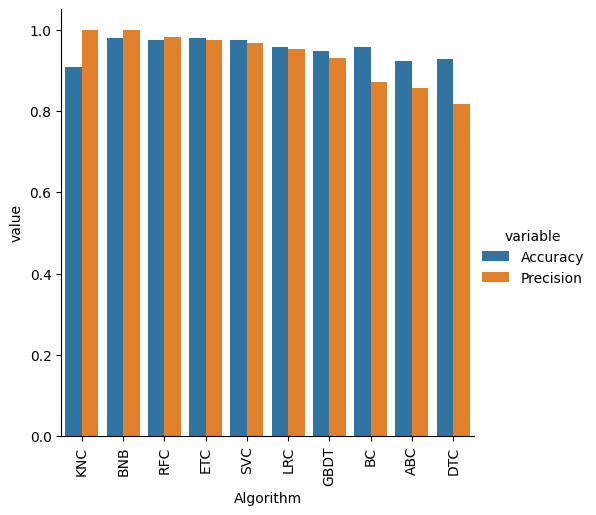

In [68]:
sns.catplot(data = dfmelt,x = 'Algorithm',y = 'value',hue='variable',kind='bar' )
plt.xticks(rotation = 'vertical')
plt.show()

In [69]:
# Model improve
# 1 : give max features of tfidf and then see ...we want to increase accuracy....And our Accuracy 
# increase...without max features accuracy is : 0.97 and with max features accuracy is : 0.98

# 2 : Then apply scaling ..Model did not improve(NB --> BNB)
# 3 : Then apply voting ..Model did not improve(NB --> BNB)
# 2 : Then apply stacking ..Model did not improve(NB --> BNB)

In [ ]:
# improve Results come after selected 3000 features in tfidf vectorizer and then apply BernoulliNB model


In [71]:
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))       #tf = TfidfVectorizer(max_features=3000)
pickle.dump(bnb,open('model.pkl','wb'))
